# Módulo 5 — Análisis Espacial: IRAG Inusitada
**Objetivo:** identificar patrones espaciales en la relación climática con IRAG.

Contenido:
1. Carga de geometrías y correlaciones
2. Mapas coropléticos (ONI y precipitación)
3. Índice de Moran global
4. Análisis LISA — clusters espaciales
5. Mapa de clusters LISA

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import libpysal
from libpysal.weights import Queen
import esda
from esda.moran import Moran, Moran_Local

# ── Configuración ─────────────────────────────────────────────────────────
DIVIPOLA_PATH  = (
    r"C:\Users\laura\OneDrive\TESIS\ETL_LauraChacon"
    r"\ETL_code\dashboard_2\divipola\divipola.parquet"
)
CORR_ONI_PATH  = (
    r"C:\Users\laura\OneDrive\TESIS\ETL_LauraChacon"
    r"\ETL_code\dashboard_3\processed\join\corr_oni_irag.parquet"
)
CORR_PRECIP_PATH = (
    r"C:\Users\laura\OneDrive\TESIS\ETL_LauraChacon"
    r"\ETL_code\dashboard_3\processed\join\corr_precip_irag.parquet"
)

ALPHA_MORAN = 0.05   # nivel de significancia para LISA

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "font.size":        10,
})
print("Librerías cargadas")

Librerías cargadas


## 1. Carga de geometrías y correlaciones

In [3]:
# Geometrías DIVIPOLA
gdf = gpd.read_parquet(DIVIPOLA_PATH)
gdf["id_mun"] = gdf["id_mun"].astype(str).str.zfill(5)
if gdf.crs is None:
    gdf = gdf.set_crs("EPSG:4326")
elif gdf.crs.to_epsg() != 4326:
    gdf = gdf.to_crs("EPSG:4326")

# Correlaciones
df_oni    = pd.read_parquet(CORR_ONI_PATH)
df_precip = pd.read_parquet(CORR_PRECIP_PATH)

df_oni["muni_code"]    = df_oni["muni_code"].astype(str).str.zfill(5)
df_precip["muni_code"] = df_precip["muni_code"].astype(str).str.zfill(5)

# Unir a geometrías
gdf_oni = gdf.merge(
    df_oni.rename(columns={"corr":"corr_oni","lag":"lag_oni",
                            "p_valor":"p_oni","sig":"sig_oni"}),
    left_on="id_mun", right_on="muni_code", how="left"
)
gdf_precip = gdf.merge(
    df_precip.rename(columns={"corr":"corr_precip","lag":"lag_precip",
                               "p_valor":"p_precip","sig":"sig_precip"}),
    left_on="id_mun", right_on="muni_code", how="left"
)

print(f"Geometrías: {len(gdf):,} municipios")
print(f"Con correlación ONI    : {gdf_oni['corr_oni'].notna().sum():,}")
print(f"Con correlación precip.: {gdf_precip['corr_precip'].notna().sum():,}")

Geometrías: 1,123 municipios
Con correlación ONI    : 851
Con correlación precip.: 851


## 2. Mapas coropléticos

C:\Users\laura\AppData\Local\Temp\ipykernel_15380\813770955.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


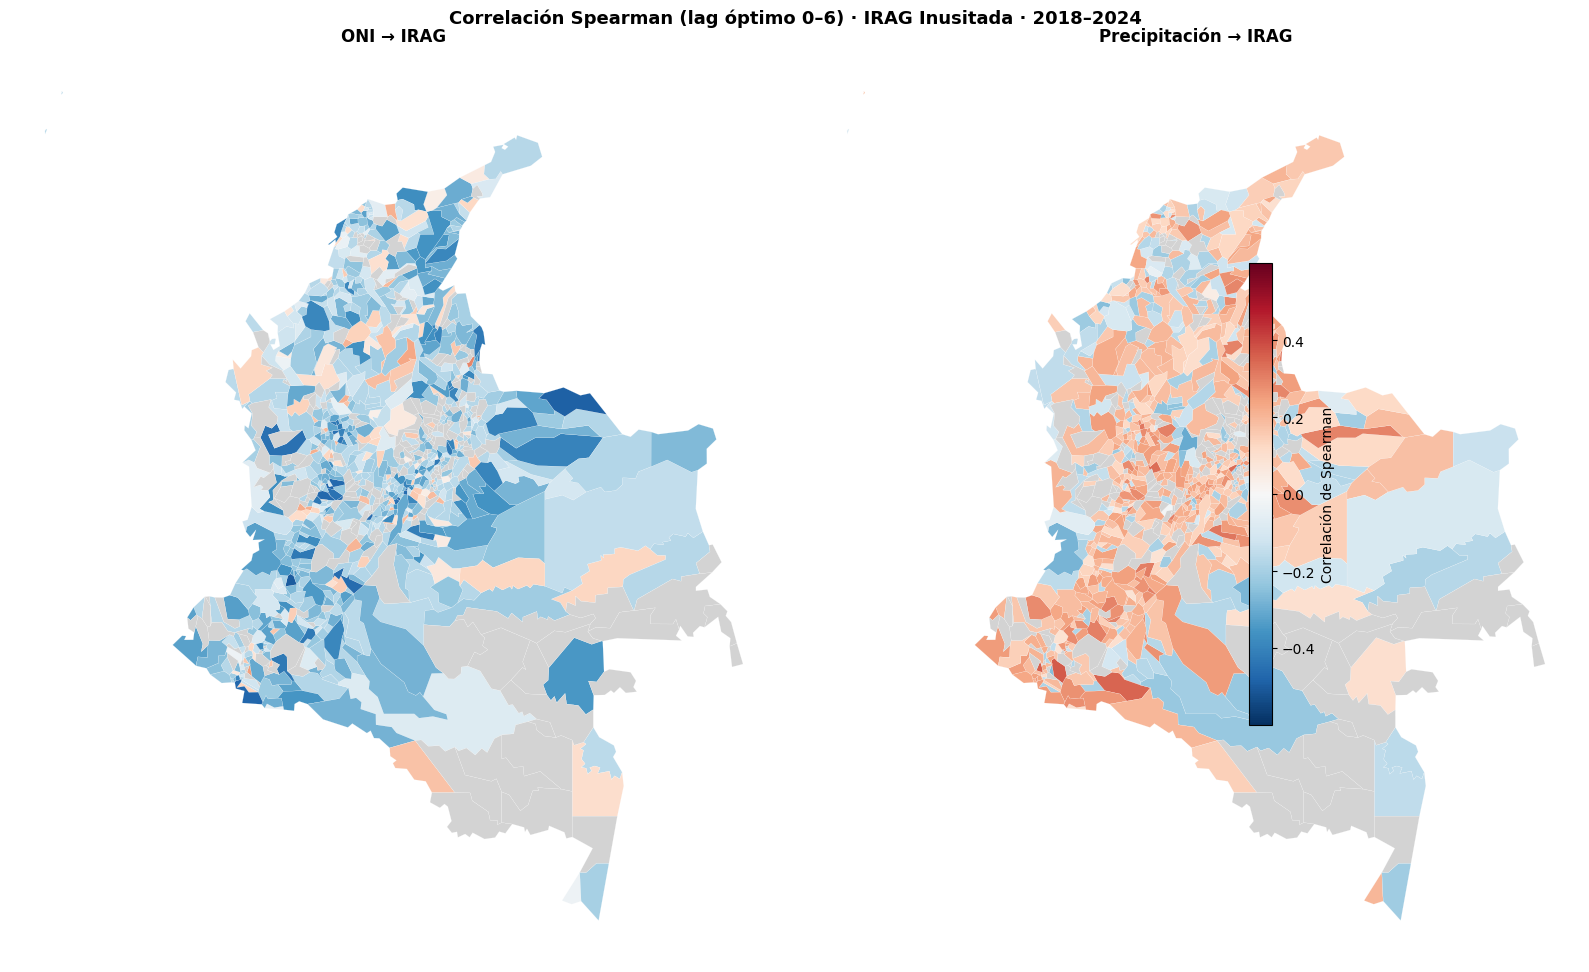

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.suptitle("Correlación Spearman (lag óptimo 0–6) · IRAG Inusitada · 2018–2024",
             fontsize=13, fontweight="bold")

norm = TwoSlopeNorm(vmin=-0.6, vcenter=0, vmax=0.6)
cmap = plt.cm.RdBu_r

# ── Mapa ONI ──────────────────────────────────────────────────────────────
gdf_oni.plot(
    column="corr_oni",
    ax=axes[0],
    cmap=cmap,
    norm=norm,
    linewidth=0.1,
    edgecolor="white",
    missing_kwds={"color": "lightgray", "label": "Sin datos"},
)
axes[0].set_title("ONI → IRAG", fontweight="bold", fontsize=12)
axes[0].set_axis_off()

# ── Mapa Precipitación ────────────────────────────────────────────────────
gdf_precip.plot(
    column="corr_precip",
    ax=axes[1],
    cmap=cmap,
    norm=norm,
    linewidth=0.1,
    edgecolor="white",
    missing_kwds={"color": "lightgray", "label": "Sin datos"},
)
axes[1].set_title("Precipitación → IRAG", fontweight="bold", fontsize=12)
axes[1].set_axis_off()

# Barra de color compartida
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02)
cbar.set_label("Correlación de Spearman", fontsize=10)

plt.tight_layout()
plt.show()

## 3. Índice de Moran global

In [5]:
def calcular_moran(gdf_var: gpd.GeoDataFrame, col: str,
                   nombre: str) -> Moran:
    """
    Calcula el índice de Moran global para una variable en el GeoDataFrame.
    Usa pesos Queen (municipios que comparten borde o vértice son vecinos).
    Excluye municipios sin dato.
    """
    gdf_v = gdf_var[gdf_var[col].notna()].copy().reset_index(drop=True)

    # Pesos espaciales Queen
    w = Queen.from_dataframe(gdf_v, silence_warnings=True)
    w.transform = "r"   # row-standardization

    moran = Moran(gdf_v[col], w)

    print(f"\nÍndice de Moran Global — {nombre}")
    print(f"  I de Moran : {moran.I:.4f}")
    print(f"  p-valor    : {moran.p_sim:.4f}")
    print(f"  z-score    : {moran.z_sim:.4f}")
    sig = "✓ Significativo" if moran.p_sim < ALPHA_MORAN else "✗ No significativo"
    print(f"  Resultado  : {sig} (α={ALPHA_MORAN})")
    if moran.I > 0 and moran.p_sim < ALPHA_MORAN:
        print("  Interpretación: los municipios vecinos tienden a tener "
              "correlaciones similares (clustering espacial positivo)")
    elif moran.I < 0 and moran.p_sim < ALPHA_MORAN:
        print("  Interpretación: los municipios vecinos tienden a tener "
              "correlaciones opuestas (dispersión espacial)")
    else:
        print("  Interpretación: distribución espacial aleatoria")
    return moran


print("=" * 55)
print("ÍNDICE DE MORAN GLOBAL")
print("=" * 55)
moran_oni    = calcular_moran(gdf_oni,    "corr_oni",    "ONI → IRAG")
moran_precip = calcular_moran(gdf_precip, "corr_precip", "Precipitación → IRAG")

ÍNDICE DE MORAN GLOBAL


C:\Users\laura\AppData\Local\Temp\ipykernel_15380\1848105590.py:11: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_v, silence_warnings=True)



Índice de Moran Global — ONI → IRAG
  I de Moran : 0.1287
  p-valor    : 0.0010
  z-score    : 5.5770
  Resultado  : ✓ Significativo (α=0.05)
  Interpretación: los municipios vecinos tienden a tener correlaciones similares (clustering espacial positivo)


C:\Users\laura\AppData\Local\Temp\ipykernel_15380\1848105590.py:11: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_v, silence_warnings=True)



Índice de Moran Global — Precipitación → IRAG
  I de Moran : 0.1479
  p-valor    : 0.0010
  z-score    : 6.3284
  Resultado  : ✓ Significativo (α=0.05)
  Interpretación: los municipios vecinos tienden a tener correlaciones similares (clustering espacial positivo)


## 4. Análisis LISA — clusters espaciales locales

In [6]:
def calcular_lisa(gdf_var: gpd.GeoDataFrame,
                  col: str) -> gpd.GeoDataFrame:
    """
    Calcula LISA (Moran Local) y clasifica cada municipio en:
        HH  Alto-Alto  (hotspot: municipio alto rodeado de vecinos altos)
        LL  Bajo-Bajo  (coldspot: municipio bajo rodeado de vecinos bajos)
        HL  Alto-Bajo  (outlier: municipio alto rodeado de vecinos bajos)
        LH  Bajo-Alto  (outlier: municipio bajo rodeado de vecinos altos)
        NS  No significativo
    """
    gdf_v = gdf_var[gdf_var[col].notna()].copy().reset_index(drop=True)

    w = Queen.from_dataframe(gdf_v, silence_warnings=True)
    w.transform = "r"

    lisa = Moran_Local(gdf_v[col], w, seed=42)

    # Clasificar cuadrantes
    media = gdf_v[col].mean()
    lag_esp = libpysal.weights.lag_spatial(w, gdf_v[col].values)

    cluster = []
    for i in range(len(gdf_v)):
        if lisa.p_sim[i] >= ALPHA_MORAN:
            cluster.append("NS")
        elif gdf_v[col].iloc[i] >= media and lag_esp[i] >= media:
            cluster.append("HH")
        elif gdf_v[col].iloc[i] < media and lag_esp[i] < media:
            cluster.append("LL")
        elif gdf_v[col].iloc[i] >= media and lag_esp[i] < media:
            cluster.append("HL")
        else:
            cluster.append("LH")

    gdf_v["lisa_cluster"] = cluster
    gdf_v["lisa_I"]       = lisa.Is
    gdf_v["lisa_p"]       = lisa.p_sim

    print(f"\nDistribución de clusters LISA ({col}):")
    print(gdf_v["lisa_cluster"].value_counts().to_string())

    return gdf_v


print("Calculando LISA para ONI → IRAG...")
gdf_lisa_oni = calcular_lisa(gdf_oni, "corr_oni")

print("\nCalculando LISA para Precipitación → IRAG...")
gdf_lisa_precip = calcular_lisa(gdf_precip, "corr_precip")

Calculando LISA para ONI → IRAG...


C:\Users\laura\AppData\Local\Temp\ipykernel_15380\834630693.py:13: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_v, silence_warnings=True)
C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\esda\moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
C:\Users\laura\AppData\Local\Temp\ipykernel_15380\834630693.py:13: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf_v, silence_warnings=True)



Distribución de clusters LISA (corr_oni):
lisa_cluster
NS    725
LL     60
HH     34
LH     20
HL     12

Calculando LISA para Precipitación → IRAG...

Distribución de clusters LISA (corr_precip):
lisa_cluster
NS    685
HH     76
HL     45
LL     35
LH     10


C:\Users\laura\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\esda\moran.py:1354: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


## 5. Mapa de clusters LISA

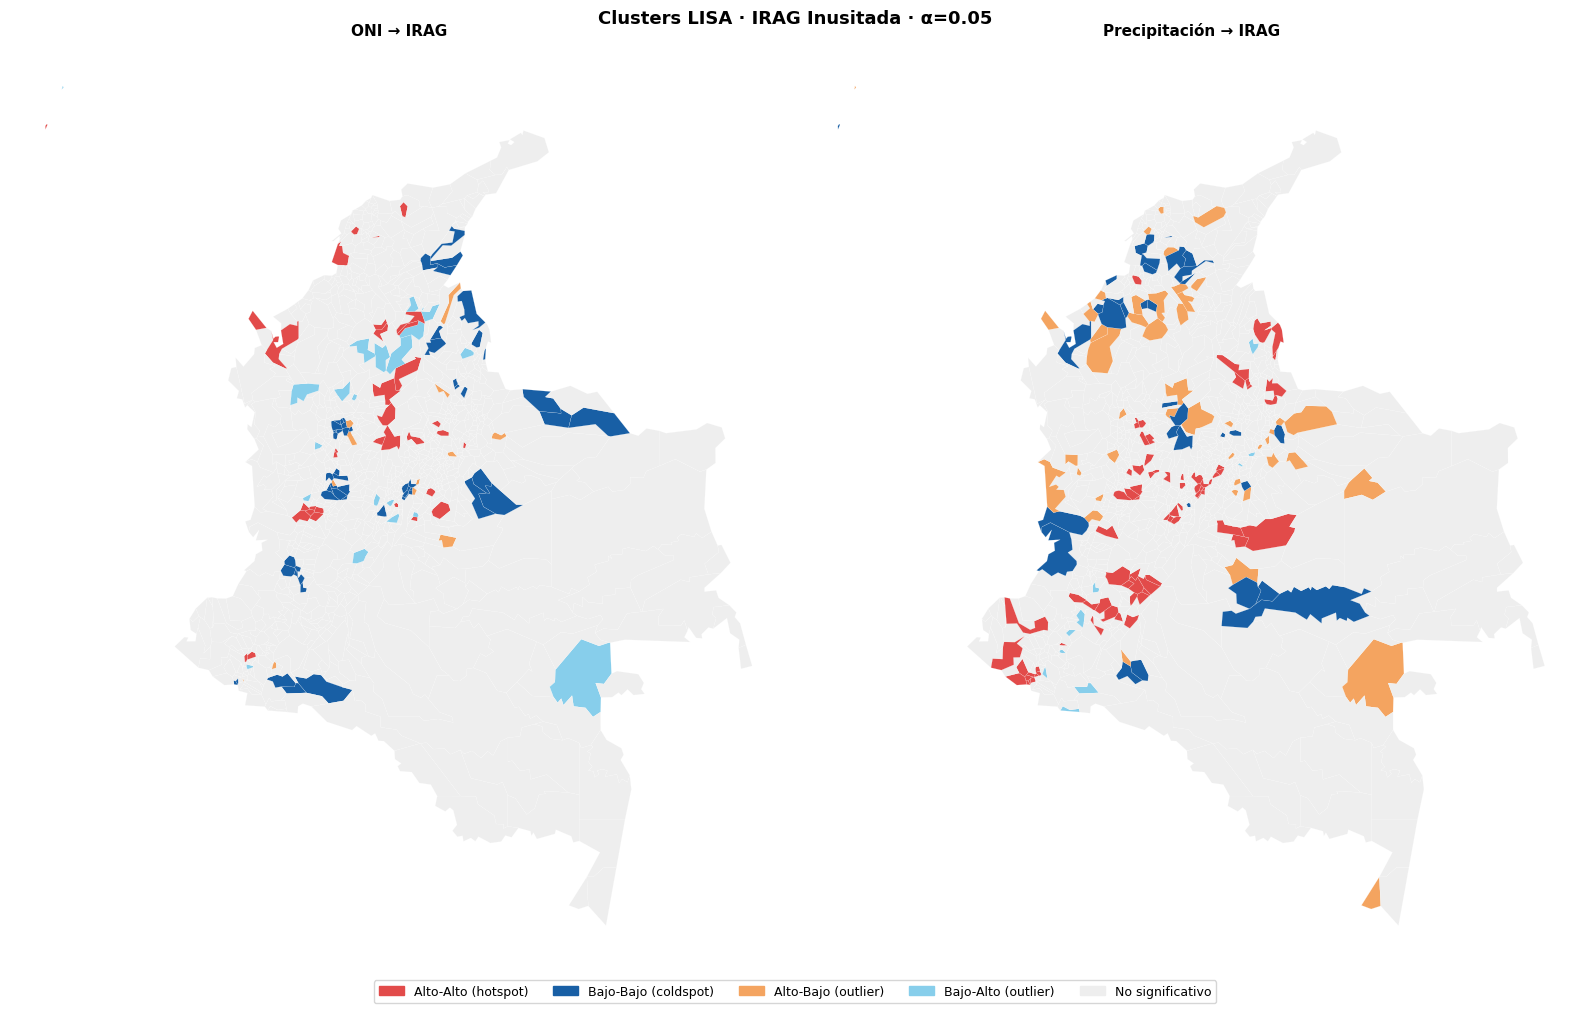

In [7]:
COLORES_LISA = {
    "HH": "#E24B4A",   # rojo   — hotspot
    "LL": "#185FA5",   # azul   — coldspot
    "HL": "#F4A460",   # naranja — outlier alto
    "LH": "#87CEEB",   # celeste — outlier bajo
    "NS": "#EEEEEE",   # gris   — no significativo
}

ETIQUETAS_LISA = {
    "HH": "Alto-Alto (hotspot)",
    "LL": "Bajo-Bajo (coldspot)",
    "HL": "Alto-Bajo (outlier)",
    "LH": "Bajo-Alto (outlier)",
    "NS": "No significativo",
}


def graficar_lisa(gdf_lisa: gpd.GeoDataFrame, titulo: str,
                  ax: plt.Axes) -> None:
    gdf_base = gdf.copy()
    gdf_base = gdf_base.merge(
        gdf_lisa[["id_mun", "lisa_cluster"]],
        on="id_mun", how="left"
    )
    gdf_base["lisa_cluster"] = gdf_base["lisa_cluster"].fillna("NS")
    gdf_base["color"] = gdf_base["lisa_cluster"].map(COLORES_LISA)

    gdf_base.plot(
        color=gdf_base["color"],
        ax=ax,
        linewidth=0.1,
        edgecolor="white",
    )
    ax.set_title(titulo, fontweight="bold", fontsize=11)
    ax.set_axis_off()


fig, axes = plt.subplots(1, 2, figsize=(16, 10))
fig.suptitle(
    f"Clusters LISA · IRAG Inusitada · α={ALPHA_MORAN}",
    fontsize=13, fontweight="bold"
)

graficar_lisa(gdf_lisa_oni,    "ONI → IRAG",          axes[0])
graficar_lisa(gdf_lisa_precip, "Precipitación → IRAG", axes[1])

# Leyenda compartida
parches = [
    mpatches.Patch(color=color, label=ETIQUETAS_LISA[cat])
    for cat, color in COLORES_LISA.items()
]
fig.legend(
    handles=parches,
    loc="lower center",
    ncol=5,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, -0.02),
)

plt.tight_layout()
plt.show()

In [8]:
# ── Resumen final ─────────────────────────────────────────────────────────
print("=" * 55)
print("RESUMEN MÓDULO 5")
print("=" * 55)
print(f"\nMoran Global ONI → IRAG:")
print(f"  I = {moran_oni.I:.4f} · p = {moran_oni.p_sim:.4f}")
print(f"\nMoran Global Precipitación → IRAG:")
print(f"  I = {moran_precip.I:.4f} · p = {moran_precip.p_sim:.4f}")

print(f"\nClusters LISA ONI:")
print(gdf_lisa_oni["lisa_cluster"].value_counts().to_string())

print(f"\nClusters LISA Precipitación:")
print(gdf_lisa_precip["lisa_cluster"].value_counts().to_string())
print("=" * 55)

RESUMEN MÓDULO 5

Moran Global ONI → IRAG:
  I = 0.1287 · p = 0.0010

Moran Global Precipitación → IRAG:
  I = 0.1479 · p = 0.0010

Clusters LISA ONI:
lisa_cluster
NS    725
LL     60
HH     34
LH     20
HL     12

Clusters LISA Precipitación:
lisa_cluster
NS    685
HH     76
HL     45
LL     35
LH     10
